In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn import manifold
from sklearn import tree
from sklearn import metrics
from sklearn import model_selection

%matplotlib inline

In [24]:
df = pd.read_csv("winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [25]:
df["quality"] -= 3
df_train = df.head(1000)
df_test = df.tail(599)

# columns = ["fixed acidity",
#            "volatile acidity",
#            "citric acid",
#            "residual sugar",
#            "chlorides",
#            "free sulfur dioxide",
#            "total sulfur dioxide",
#            "density",
#            "pH",
#            "sulphates",
#            "alcohol"]

columns = df.columns.tolist()
# print(columns)

columns.remove("quality")
# print(columns)

df
# df_train
# df_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,2
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,3
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,3
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,2


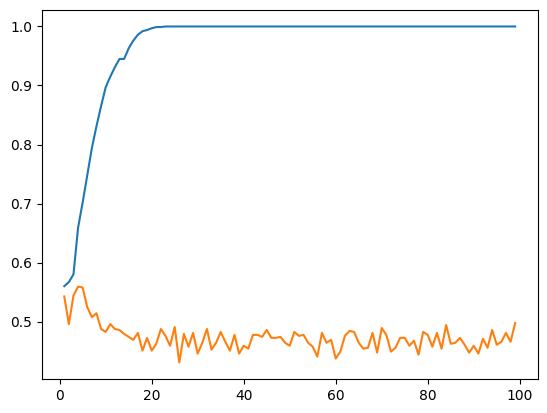

In [26]:
train_accuracy = []
test_accuracy = []

for x in range(1, 100):
    decision_tree = tree.DecisionTreeClassifier(max_depth=x)

    decision_tree.fit(df_train[columns], df_train["quality"])
    train_predictions = decision_tree.predict(df_train[columns])
    test_predictions = decision_tree.predict(df_test[columns])

    tr = metrics.accuracy_score(df_train["quality"], train_predictions)
    te = metrics.accuracy_score(df_test["quality"], test_predictions)
    
    train_accuracy.append(tr)
    test_accuracy.append(te)
    
x_values = [i for i in range(1, 100)];

plt.plot(x_values, train_accuracy)
plt.plot(x_values, test_accuracy)
plt.show()

In [2]:
df = pd.read_csv("winequality-red.csv")

df["kfold"] = -1

df = df.sample(frac=1).reset_index(drop=True)

y = df.quality.values
print(y)

# kf = model_selection.KFold(n_splits = 5)
kf = model_selection.StratifiedKFold(n_splits = 5)

for fold, (trn_, val_) in enumerate(kf.split(X=df, y=y)):
    df.loc[val_, 'kfold'] = fold

df.to_csv("train_folds.csv", index=False)

[3 5 5 ... 5 5 7]


In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kfold
0,6.8,0.815,0.00,1.2,0.267,16.0,29.0,0.99471,3.32,0.51,9.8,3,0
1,6.1,0.340,0.25,1.8,0.084,4.0,28.0,0.99464,3.36,0.44,10.1,5,0
2,8.1,0.785,0.52,2.0,0.122,37.0,153.0,0.99690,3.21,0.69,9.3,5,0
3,7.2,0.360,0.46,2.1,0.074,24.0,44.0,0.99534,3.40,0.85,11.0,7,0
4,7.2,0.570,0.05,2.3,0.081,16.0,36.0,0.99564,3.38,0.60,10.3,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,8.2,0.240,0.34,5.1,0.062,8.0,22.0,0.99740,3.22,0.94,10.9,6,4
1595,7.8,0.560,0.19,2.0,0.081,17.0,108.0,0.99620,3.32,0.54,9.5,5,4
1596,9.9,0.740,0.19,5.8,0.111,33.0,76.0,0.99878,3.14,0.55,9.4,5,4
1597,10.4,0.280,0.54,2.7,0.105,5.0,19.0,0.99880,3.25,0.63,9.5,5,4
